## Basic ChatBot with LangGraph

In [1]:
from typing import Annotated
import langchain
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END



In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]



In [3]:
print(State)

<class '__main__.State'>


In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
## llm
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")

##llm.invoke('hi')

In [6]:
## for every node we need to create a definition 

## node which has state + llm
def ChatBot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [7]:
## intialize graph
graph_builder = StateGraph(State)

## add node to the graph
graph_builder.add_node("llmchatbot", ChatBot)

## add edges to the graph
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

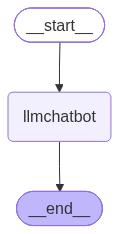

In [8]:

## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [9]:
from langchain_core.messages import HumanMessage
response = graph.invoke({"messages": "hi"})

response["messages"][-1].content


'How can I assist you today?'

In [10]:
for event in graph.stream({"messages": "Hi"}):
    for value in event.values():
        print(value["messages"][-1].content)

It's nice to meet you. Is there something I can help you with or would you like to chat?


## chatbot with tool

In [ ]:
from langchain_tavily import TavilySearch

## tool 1
search_tool = TavilySearch(max_result=2)
search_tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [ ]:
## Custom function
from langchain_core.tools import tool
## tool 2
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b

In [28]:
tools = [search_tool, multiply]

llm_with_tools = llm.bind_tools(tools)

In [29]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000233A44B7410>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000233A45777D0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [30]:
## stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## state
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}



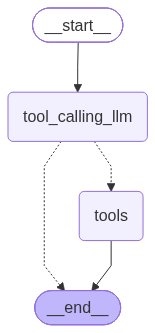

In [32]:
## Graph

builder = StateGraph(State)

# add node 1 
builder.add_node("tool_calling_llm", tool_calling_llm)

# add node 2
builder.add_node("tools", ToolNode(tools))

# add edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)


## compile
graph = builder.compile()

# display

display(Image(graph.get_graph().draw_mermaid_png()))



In [34]:
response = graph.invoke({"messages": "what is the recent kashmir news?"})

In [35]:
response["messages"][-1].content

'{"query": "latest Kashmir developments", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cfr.org/global-conflict-tracker/conflict/conflict-between-india-and-pakistan", "title": "Conflict Between India and Pakistan | Global Conflict Tracker", "content": "Throughout 2024, violence continued in Kashmir in response to increasing efforts by New Delhi to consolidate territorial control. Attacks specifically targeted Indian travelers and workers in the region. In June 2024, militants opened fire on a bus carrying pilgrims traveling to a Hindu shrine in the town of Reasi. The attack killed nine and injured over thirty. In October, militants killed seven in Kashmir at a construction site for a tunnel project connecting Kashmir to the northern region of [...] Indian army trucks move along a highway leading to Ladakh in Kashmir’s Ganderbal district, on September 3, 2020.\\n\\nIndian army trucks move along a highway leading to Ladakh in Kashmir’s Gander

In [36]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent kashmir news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xjy18s7ym)
 Call ID: xjy18s7ym
  Args:
    query: Kashmir recent news
    start_date: 2024-01-01
    topic: news
  tavily_search (nex5a995r)
 Call ID: nex5a995r
  Args:
    query: latest Kashmir developments
    start_date: 2024-01-01
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Kashmir recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://kashmirlife.net/power-shutdown-in-kashmir-parts-89-445331", "title": "Power Shutdown In Kashmir Parts", "content": "SRINAGAR: The Kashmir Power Distribution Corporation Limited (KPDCL) has announced scheduled power shutdowns in parts of Pulwama and", "score": 0.5976789, "published_date": "Tue, 28 Jul

In [37]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (nnvt5cjtd)
 Call ID: nnvt5cjtd
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [38]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (h257z7qmr)
 Call ID: h257z7qmr
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (cx2pevhk9)
 Call ID: cx2pevhk9
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nytimes.com/2026/07/29/business/skhynix-chips-memory.html", "title": "South Korea's Memory Chip Giant Defies A.I. Market Jitters", "content": "And no company has been more exposed to the wild stock-market gyrations that have roiled A.I. companies in recent weeks. Hynix has been a focal point for investor concerns over the seemingly runaway costs of Silicon Val